This notebook explores hard dirichlet enforcement on the cuette flow. 

In [1]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import datetime
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm
from typing import Tuple

%load_ext autoreload
%autoreload 2

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_TEMP_SAVE_PATH = './most_eff_model.pt'
NU = 1 / 100
RE = 1 / NU
T_MAX = 1
L_BOUNDS = [0, -0.05]
U_BOUNDS = [1, 0.05]
A = 0.3 

In [3]:
# NOTE: input is assumed to have requires_grad=True
def pde_res(output: torch.Tensor, input: torch.Tensor) -> Tuple[torch.Tensor]:
    u, v, p = output[:, 0:1], output[:, 1:2], output[:, 2:3]
    
    u_grad = grad(u, input, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, input, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]
    
    u_xx = grad(u_x, input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, input, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, input, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    p_grad = grad(p, input, torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    
    res_a = u * u_x + v * u_y + p_x - NU * (u_xx + u_yy)
    res_b = u * v_x + v * v_y + p_y - NU * (v_xx + v_yy)
    res_ct = u_x + v_y
    
    return res_a, res_b, res_ct
    
def pde_loss(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.requires_grad_(True)
    pde_out = model(pde_pts).requires_grad_(True)
    pde_res_a, pde_res_b, pde_res_ct  = pde_res(pde_out, pde_pts)
    return [torch.mean(pde_res_a**2 + pde_res_b**2 + pde_res_ct**2)]

In [4]:
# defining the smooth bump function

def f(x: float) -> float:
    return torch.where(x > 0, torch.exp(-1/x), 0)
    
def g(x: float) -> float:
    return f(x) / (f(x) + f(1 - x))

delta = 0.4


from numpy import pi

K = 2
A = 1e-2

def smoothing_fn(x: torch.Tensor):
    return A * ((0.1/2)**K - torch.abs(x[:, 1:2])**K)
    
P_IN = 0.1
P_OUT = 0.0
    
def decorator(x: torch.Tensor, out: torch.Tensor):
    return torch.cat([
        torch.mul(smoothing_fn(x), out[:, 0:2]),
        ((x[:, 0:1] - L_BOUNDS[0]) * P_OUT + (U_BOUNDS[0] - x[:, 0:1]) * P_IN) / (U_BOUNDS[0] - L_BOUNDS[0]) +\
            (x[:, 0:1] - L_BOUNDS[0]) * (U_BOUNDS[0] - x[:, 0:1]) * out[:, 2:3]
    ], dim=1)

In [ ]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=3,
    layer=[32, 32, 32, 32],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce=True,
    decorator=decorator
)

model = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_VALUE)

def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight, gain=torch.nn.init.calculate_gain('tanh'))
        torch.nn.init.zeros_(m.bias)

model.apply(init_weights)

TypeError: ModelContext.__init__() got an unexpected keyword argument 'hard_enforce_boundary'

In [ ]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin',
    N_int=2_000,
    N_sides=[(0, 0), (0, 0)],
)

domain = cb.CubeDomain(domain_ctx)

In [ ]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=pde_loss,
    resample=False,
    epochs=50_000,
    monitor_gradient=True,
    monitor_lr=True
)

_, _ = train.simple_train(train_ctx)

Loss at epoch 1 is: 169.82737731933594. Total gradient norm: 4069.0608439485222 Current learing rate: 0.001 
Loss at epoch 100 is: 0.17770658433437347. Total gradient norm: 4.977598403986384 Current learing rate: 0.001 
Loss at epoch 200 is: 0.07721979916095734. Total gradient norm: 1.2550951837802158 Current learing rate: 0.001 
Loss at epoch 300 is: 0.05144437029957771. Total gradient norm: 0.6117856483952802 Current learing rate: 0.001 
Loss at epoch 400 is: 0.03986532613635063. Total gradient norm: 0.4135154224935576 Current learing rate: 0.001 
Loss at epoch 500 is: 0.03220890089869499. Total gradient norm: 0.3264449511491809 Current learing rate: 0.001 
Loss at epoch 600 is: 0.026573482900857925. Total gradient norm: 0.2710751783028068 Current learing rate: 0.001 
Loss at epoch 700 is: 0.022249329835176468. Total gradient norm: 0.23014040905750482 Current learing rate: 0.001 
Loss at epoch 800 is: 0.018833456560969353. Total gradient norm: 0.19789571319056132 Current learing rate

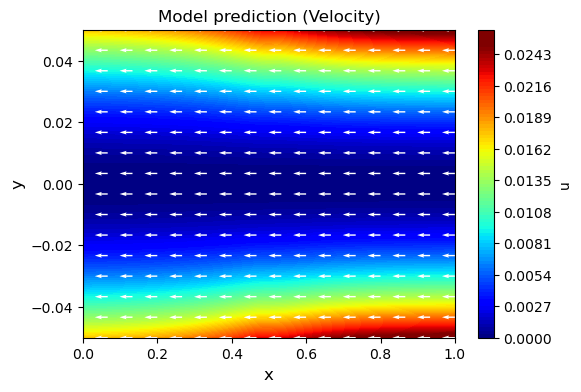

In [ ]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['u'],
    titles= ['Model prediction (Velocity)'],
    device=device,
    vmin=0,
    vmax=0.025,
    patches=[],
    N = 100
)

def velocity(x: torch.Tensor) -> torch.Tensor:
    x.requires_grad_(True)
    out = model(x)
    u = out[:, 0:1]
    v = out[:, 1:2]
    
    return torch.cat([u, v], dim=1)

utils.plot_vector_field_2d([velocity], plot_ctx, N=100, n_width=16, n_heigth=16)


plot_ctx.vmin=-0.53
plot_ctx.vmax=-0.43
plot_ctx.titles = ['Model prediction (Streamfunction)']
plot_ctx.function_names = [r'$\psi$']